# 🛒 Shopper Spectrum

## Data Cleaning

### Business Objective

The objective of this phase is to clean the raw e-commerce transaction dataset by handling missing values, duplicate records, cancelled invoices, and invalid transactions. A clean dataset ensures accurate exploratory data analysis, customer segmentation, and product recommendation in the later stages of the project.

---

In [7]:
# ==========================================================
# Shopper Spectrum - Data Cleaning
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

In [57]:
df.to_csv(
    r"C:\Users\saura\Desktop\SHOPPER_SPECTRUM\data\cleaned_online_retail.csv",
    index=False
)
print("Dataset loaded ✅")

Dataset loaded ✅


In [9]:
# ==========================================================
# Display First 5 Rows
# ==========================================================

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
# ==========================================================
# Check Dataset Shape
# ==========================================================

print("Number of Rows and Columns:")
df.shape

Number of Rows and Columns:


(541909, 8)

In [11]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [12]:
# ==========================================================
# Missing Values
# ==========================================================

missing_values = df.isnull().sum()

missing_values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
# ==========================================================
# Missing Values Percentage
# ==========================================================

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

## Step 1: Handling Missing CustomerID

### Observation
The CustomerID column contains missing values.

### Business Reason
CustomerID is essential for customer segmentation (RFM Analysis). Without a CustomerID, transactions cannot be linked to a specific customer.

### Action Taken
Remove rows where CustomerID is missing.

In [14]:
# ==========================================================
# Missing Values Before Cleaning
# ==========================================================

print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [15]:
# Store original number of rows
original_rows = len(df)

print(f"Original Rows: {original_rows}")

Original Rows: 541909


In [16]:
# ==========================================================
# Remove rows with missing CustomerID
# ==========================================================

df = df.dropna(subset=["CustomerID"])

In [17]:
# Check missing values after cleaning
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [18]:
# ==========================================================
# Rows Removed
# ==========================================================

removed_rows = original_rows - len(df)

print(f"Rows removed: {removed_rows}")
print(f"Remaining rows: {len(df)}")

Rows removed: 135080
Remaining rows: 406829


### Result

- Removed **135,080** records with missing CustomerID.
- Remaining dataset contains **406,829** records.
- The dataset is now suitable for customer-level analysis such as RFM segmentation and product recommendations.

## Step 2: Remove Cancelled Invoices

### Observation

Some invoice numbers begin with the letter **"C"**, indicating cancelled transactions.

### Business Reason

Cancelled invoices do not represent completed customer purchases and should not be included in customer behavior analysis.

### Action Taken

Removed all cancelled invoices where InvoiceNo starts with "C".

In [19]:
# ==========================================================
# Count Cancelled Invoices
# ==========================================================

cancelled_orders = df['InvoiceNo'].astype(str).str.startswith('C').sum()

print(f"Cancelled Invoices: {cancelled_orders}")

Cancelled Invoices: 8905


In [20]:
# ==========================================================
# Remove Cancelled Invoices
# ==========================================================

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [21]:
# ==========================================================
# Verify Cancellation Removal
# ==========================================================

remaining_cancelled = df['InvoiceNo'].astype(str).str.startswith('C').sum()

print(f"Remaining Cancelled Invoices: {remaining_cancelled}")

Remaining Cancelled Invoices: 0


## Step 3: Remove Invalid Quantity

### Observation

Some transactions have a Quantity less than or equal to zero.

### Business Reason

Negative or zero quantities do not represent successful customer purchases. They usually indicate product returns, stock adjustments, or administrative corrections.

### Action Taken

Removed all records where Quantity is less than or equal to zero.

In [22]:
# ==========================================================
# Check Invalid Quantity
# ==========================================================

invalid_quantity = (df["Quantity"] <= 0).sum()

print(f"Invalid Quantity Records: {invalid_quantity}")

Invalid Quantity Records: 0


In [23]:
# ==========================================================
# Remove Invalid Quantity
# ==========================================================

df = df[df["Quantity"] > 0]

In [24]:
# ==========================================================
# Verify Quantity Cleaning
# ==========================================================

remaining_invalid = (df["Quantity"] <= 0).sum()

print(f"Remaining Invalid Quantity: {remaining_invalid}")

Remaining Invalid Quantity: 0


In [25]:
print("Dataset Shape After Quantity Cleaning:")
print(df.shape)

Dataset Shape After Quantity Cleaning:
(397924, 8)


## Step 4: Remove Invalid UnitPrice

### Observation

Some transactions have a UnitPrice less than or equal to zero.

### Business Reason

Products with zero or negative prices do not represent actual sales transactions and can distort revenue analysis and customer spending patterns.

### Action Taken

Removed all records where UnitPrice is less than or equal to zero.

In [26]:
# ==========================================================
# Check Invalid UnitPrice
# ==========================================================

invalid_price = (df["UnitPrice"] <= 0).sum()

print(f"Invalid Price Records: {invalid_price}")

Invalid Price Records: 40


In [27]:
# ==========================================================
# Remove Invalid UnitPrice
# ==========================================================

df = df[df["UnitPrice"] > 0]

In [28]:
remaining_invalid_price = (df["UnitPrice"] <= 0).sum()

print(f"Remaining Invalid Prices: {remaining_invalid_price}")

Remaining Invalid Prices: 0


In [29]:
print("Dataset Shape After UnitPrice Cleaning:")
print(df.shape)

Dataset Shape After UnitPrice Cleaning:
(397884, 8)


## Step 5: Handle Duplicate Records

### Observation

The dataset may contain duplicate transaction records.

### Business Reason

Duplicate records can lead to incorrect sales, revenue, and customer behavior analysis by counting the same transaction multiple times.

### Action Taken

Checked for duplicate records and removed them if found.

In [30]:
# ==========================================================
# Check Duplicate Records
# ==========================================================

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 5192


In [31]:
# ==========================================================
# Remove Duplicate Records
# ==========================================================

df = df.drop_duplicates()

In [32]:
remaining_duplicates = df.duplicated().sum()

print(f"Remaining Duplicates: {remaining_duplicates}")

Remaining Duplicates: 0


In [33]:
print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(392692, 8)


### Result

All duplicate records were successfully removed.

The dataset now contains only unique and valid customer transactions, making it suitable for further business analysis.

## Step 6: Convert InvoiceDate to Datetime

### Observation

The InvoiceDate column is currently stored as text.

### Business Reason

Date-based analysis such as monthly sales trends and RFM analysis requires the InvoiceDate column to be in datetime format.

### Action Taken

Converted the InvoiceDate column into datetime format.

In [34]:
# ==========================================================
# Convert InvoiceDate to Datetime
# ==========================================================

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[us]


In [35]:
# ==========================================================
# Final Data Quality Check
# ==========================================================

print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nCancelled Invoices:",
      df["InvoiceNo"].astype(str).str.startswith("C").sum())

print("\nInvalid Quantity:",
      (df["Quantity"] <= 0).sum())

print("\nInvalid Price:",
      (df["UnitPrice"] <= 0).sum())

Missing Values
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate Records: 0

Cancelled Invoices: 0

Invalid Quantity: 0

Invalid Price: 0


In [37]:
# ==========================================================
# Save Cleaned Dataset
# ==========================================================

df.to_csv(
    r"C:\Users\saura\Desktop\SHOPPER_SPECTRUM\data\cleaned_online_retail.csv",
    index=False
)

print("Cleaned dataset saved successfully! ✅")

Cleaned dataset saved successfully! ✅


In [ ]:
import os

print(os.getcwd())

c:\Users\saura\Desktop\Shopper_Spectrum\Notebook


# Feature Engineering

## Create Revenue Column

### Business Objective

Revenue is one of the most important business metrics.

It helps us identify:

- Highest selling countries
- Best customers
- Top revenue products
- Customer Monetary Value for RFM Analysis

### Formula

Revenue = Quantity × UnitPrice

In [ ]:
# ==========================================================
# Feature Engineering
# Create Revenue Column
# ==========================================================

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# EDA 1: Country-wise Revenue Analysis

## Business Question

Which countries generate the highest revenue?

## Business Objective

Understanding country-wise revenue helps the company identify its strongest markets, prioritize marketing efforts, optimize inventory, and plan future expansion strategies.

In [ ]:
# ==========================================================
# Country-wise Revenue
# ==========================================================

country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

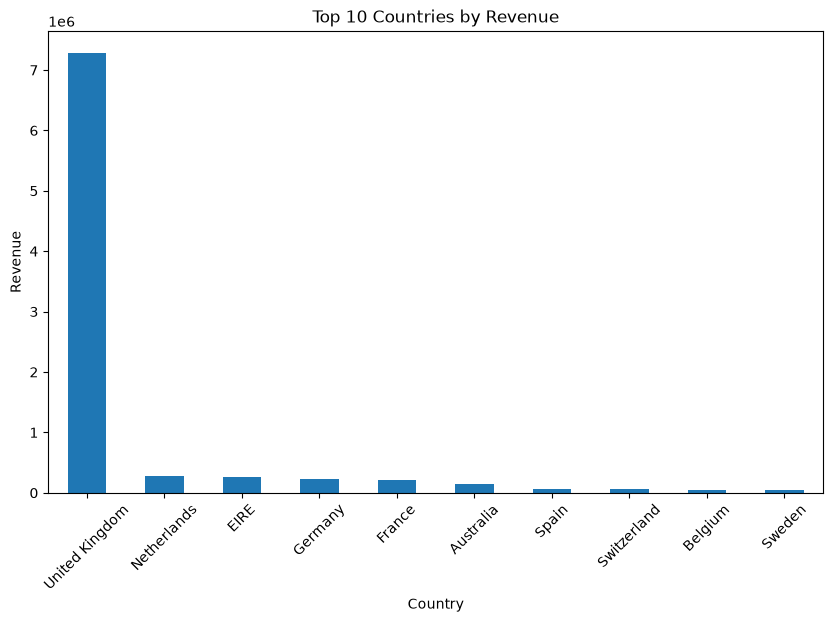

In [ ]:
import matplotlib.pyplot as plt

# Top 10 countries by revenue
top10_country = country_sales.head(10)

plt.figure(figsize=(10,6))

top10_country.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# EDA 2: Top Selling Products

## Business Question

Which products are purchased the most by customers?

## Business Objective

Identifying the most frequently purchased products helps the business optimize inventory, improve stock availability, and plan promotional campaigns.

In [ ]:
# ==========================================================
# Top 10 Selling Products
# ==========================================================

top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

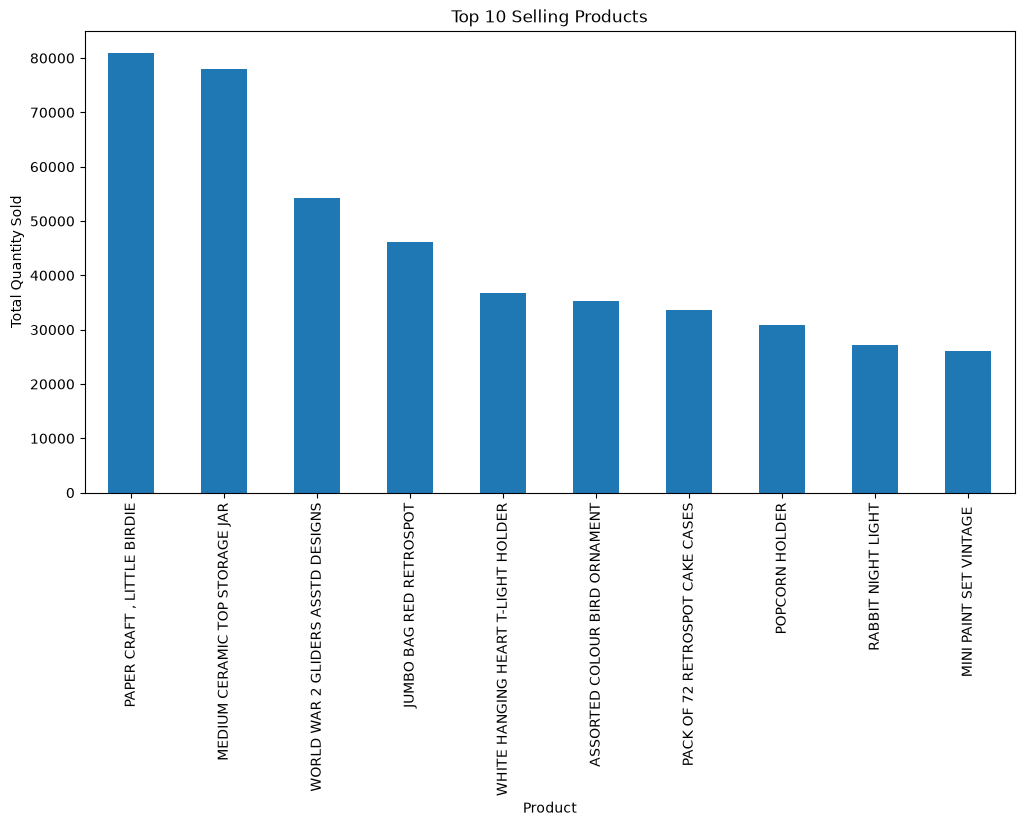

In [ ]:
plt.figure(figsize=(12,6))

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Selling Products")

plt.xlabel("Product")

plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=90)

plt.show()

### Observation

The chart displays the top 10 products based on total quantity sold.

### Business Insight

High-selling products represent consistent customer demand and should always remain adequately stocked.

### Business Recommendation

The company should prioritize inventory management for these products and consider using them in promotional bundles or marketing campaigns to maximize sales.

# EDA 3: Top Revenue-Generating Products

## Business Question

Which products generate the highest revenue?

## Business Objective

Revenue analysis helps identify premium products that contribute the most to the company's earnings.

In [ ]:
# ==========================================================
# Top Revenue Products
# ==========================================================

top_revenue_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_revenue_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

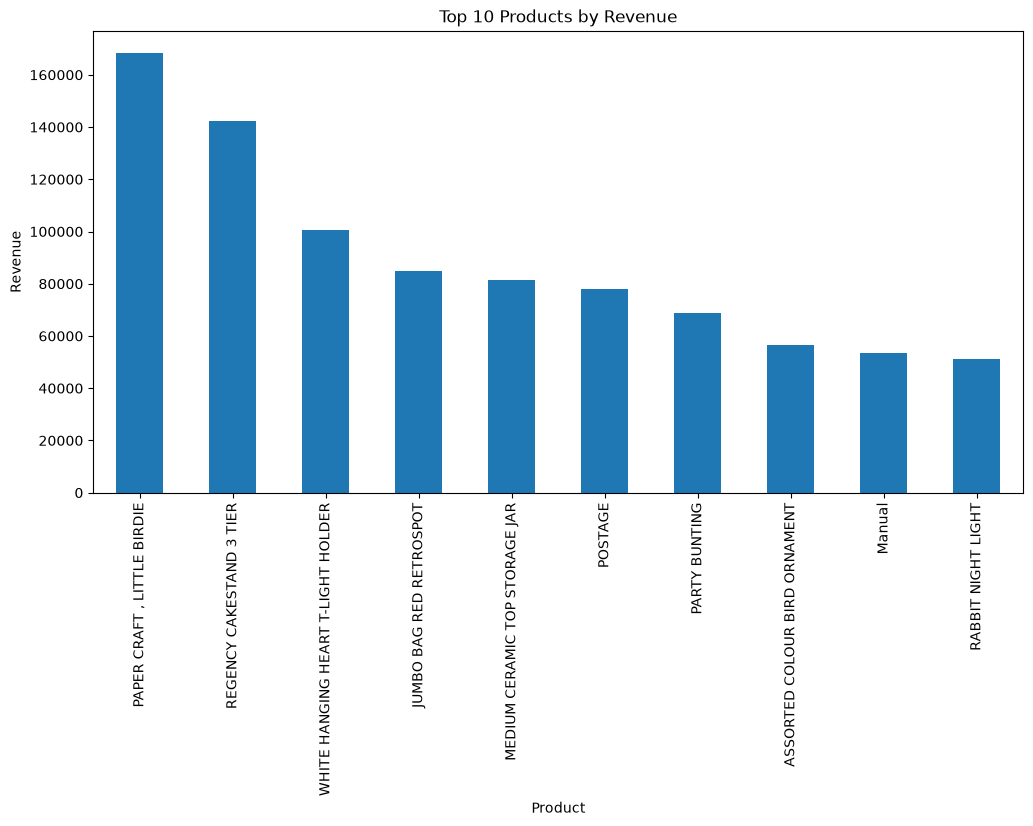

In [ ]:
plt.figure(figsize=(12,6))

top_revenue_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

### Observation

The chart displays the products generating the highest revenue.

### Business Insight

These products contribute significantly to the company's total sales despite not necessarily having the highest sales volume.

### Business Recommendation

The company should ensure consistent availability of these high-revenue products and develop premium marketing strategies to maximize profitability.

# EDA 4: Monthly Sales Trend

## Business Question

How has the company's revenue changed over time?

## Business Objective

Monthly sales analysis helps identify seasonal trends, peak sales periods, and business growth patterns, enabling better planning for inventory, marketing, and operations.

In [ ]:
# ==========================================================
# Create Year-Month Column
# ==========================================================

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [ ]:
# ==========================================================
# Monthly Revenue
# ==========================================================

monthly_sales = (
    df.groupby("YearMonth")["Revenue"]
    .sum()
)

monthly_sales

YearMonth
2022-12     570422.730
2023-01     568101.310
2023-02     446084.920
2023-03     594081.760
2023-04     468374.331
2023-05     677355.150
2023-06     660046.050
2023-07     598962.901
2023-08     644051.040
2023-09     950690.202
2023-10    1035642.450
2023-11    1156205.610
2023-12     517190.440
Freq: M, Name: Revenue, dtype: float64

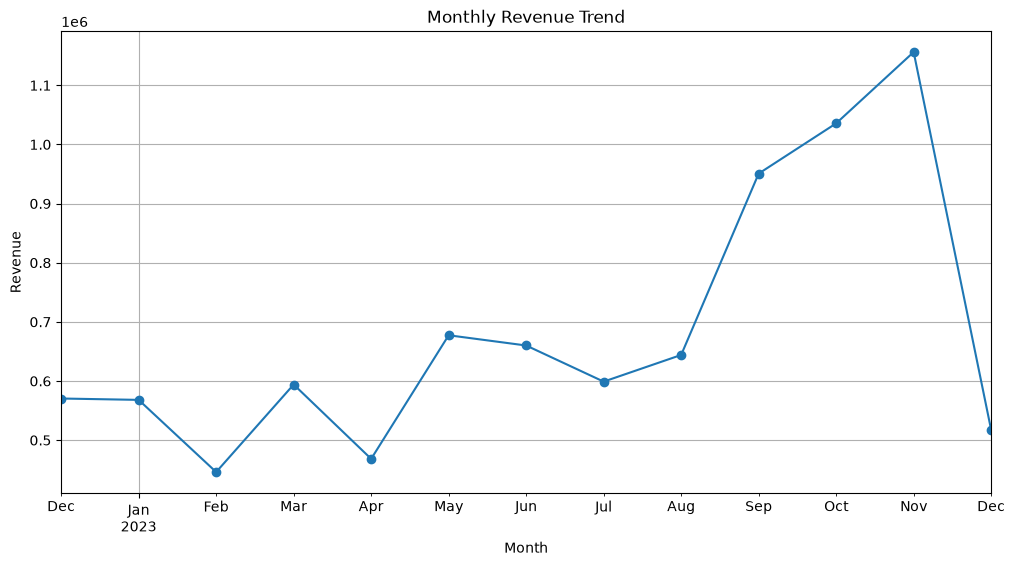

In [ ]:
plt.figure(figsize=(12,6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Observation

The line chart shows how revenue changes from month to month.

### Business Insight

The company experiences fluctuations in monthly revenue, indicating periods of higher and lower customer demand.

### Business Recommendation

The business should investigate the causes of peak and low-performing months to optimize inventory planning and marketing campaigns.

# EDA 5: Top Customers by Revenue

## Business Objective

Identifying high-value customers helps the company strengthen customer relationships, improve retention, and develop loyalty programs.

In [ ]:
# ==========================================================
# Top Customers by Revenue
# ==========================================================

top_customers = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_customers.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

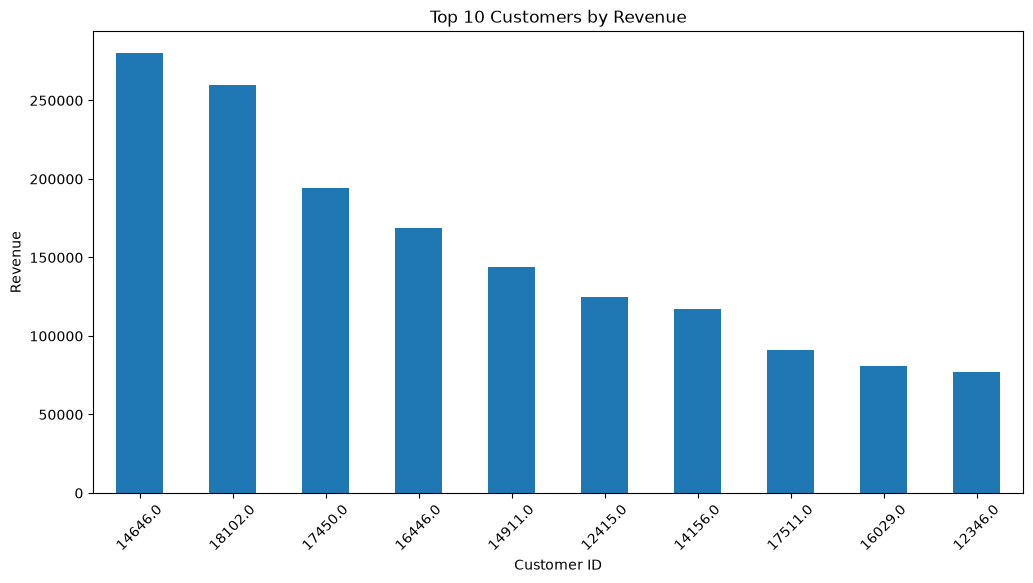

In [ ]:
plt.figure(figsize=(12,6))

top_customers.head(10).plot(kind="bar")

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customer ID")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### Observation

The chart identifies the customers who contribute the highest revenue.

### Business Insight

A small group of customers contributes significantly to the company's total revenue.

### Business Recommendation

The company should focus on retaining these high-value customers through loyalty programs, personalized offers, and premium customer service.

# EDA 6: Top Countries by Number of Orders

## Business Question

Which countries place the highest number of orders?

## Business Objective

This analysis helps identify markets with high customer activity and supports operational planning and market expansion strategies.

In [ ]:
# ==========================================================
# Top Countries by Number of Orders
# ==========================================================

country_orders = (
    df.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

country_orders.head(10)

Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Portugal             57
Australia            57
Switzerland          51
Name: InvoiceNo, dtype: int64

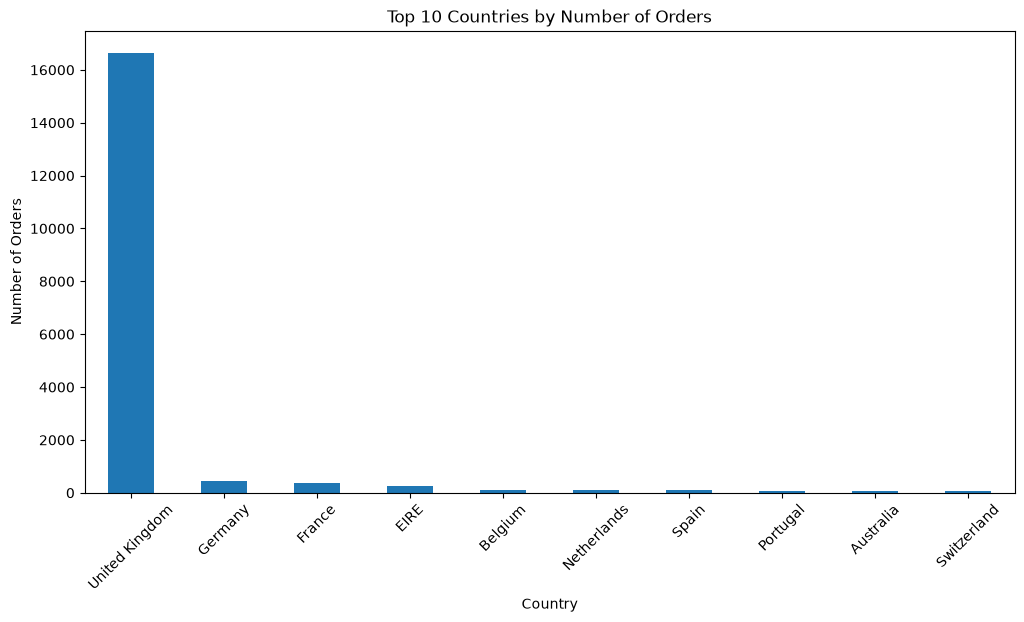

In [ ]:
plt.figure(figsize=(12,6))

country_orders.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Number of Orders")

plt.xlabel("Country")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

### Observation

The chart displays the countries with the highest number of completed orders.

### Business Insight

Countries with a high order count indicate strong customer engagement and frequent purchasing activity.

### Business Recommendation

The company should strengthen logistics and customer support in these high-demand markets.

# EDA 7: Customer Distribution by Country

## Business Question

Where are the majority of the company's customers located?

## Business Objective

Identifying countries with the highest number of unique customers helps the company understand its strongest customer markets, improve customer retention strategies, and identify opportunities for market expansion.

In [ ]:
# ==========================================================
# Customer Distribution by Country
# ==========================================================

customer_country = (
    df.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
)

customer_country.head(10)

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

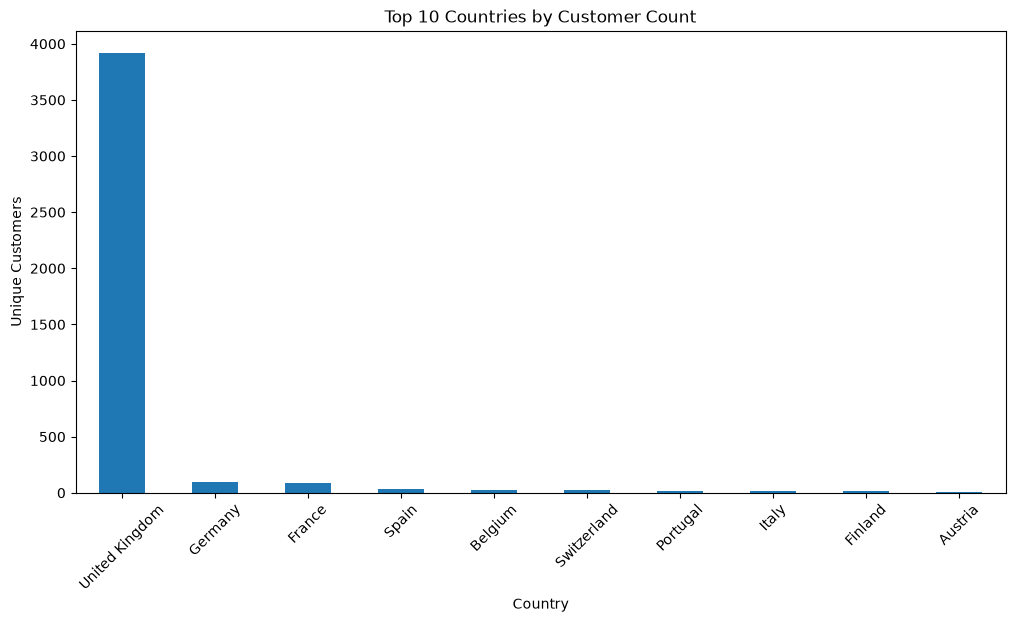

In [ ]:
plt.figure(figsize=(12,6))

customer_country.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Customer Count")

plt.xlabel("Country")

plt.ylabel("Unique Customers")

plt.xticks(rotation=45)

plt.show()

### Observation

The chart displays the top 10 countries with the highest number of unique customers.

### Business Insight

Countries with a larger customer base indicate stronger market presence and higher customer engagement. These regions contribute significantly to the company's customer network.

### Business Recommendation

The company should continue investing in customer acquisition and retention strategies in these high-performing countries while exploring opportunities to expand into countries with lower customer penetration.

# EDA 8: Revenue Distribution

## Business Question

How is revenue distributed across customer transactions?

## Business Objective

Revenue distribution analysis helps understand whether the business is driven by many low-value transactions or a few high-value purchases. This information supports pricing strategies and customer targeting.

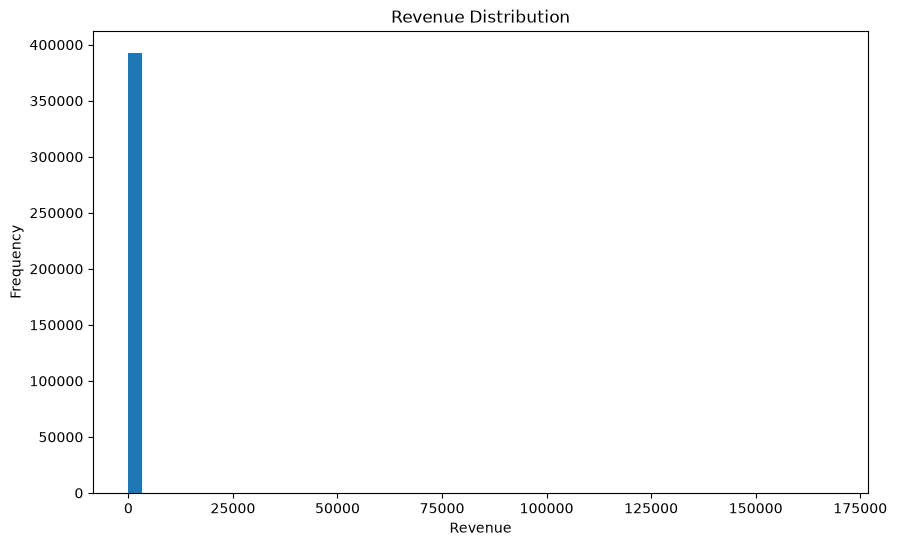

In [ ]:
# ==========================================================
# Revenue Distribution
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(df["Revenue"], bins=50)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows the distribution of revenue generated from customer transactions.

### Business Insight

The revenue distribution helps identify whether the company primarily generates income from a large number of low-value purchases or a smaller number of high-value transactions.

### Business Recommendation

If the distribution is highly skewed toward lower-value transactions, the company should focus on increasing the average order value through product bundling, upselling, and personalized recommendations.

# EDA 9: Correlation Analysis

## Business Question

What is the relationship between Quantity, UnitPrice, and Revenue?

## Business Objective

Correlation analysis helps identify how numerical variables are related to one another and provides insights into the factors that influence revenue generation.

In [ ]:
import seaborn as sns

print("Seaborn Installed Successfully! ✅")

Seaborn Installed Successfully! ✅


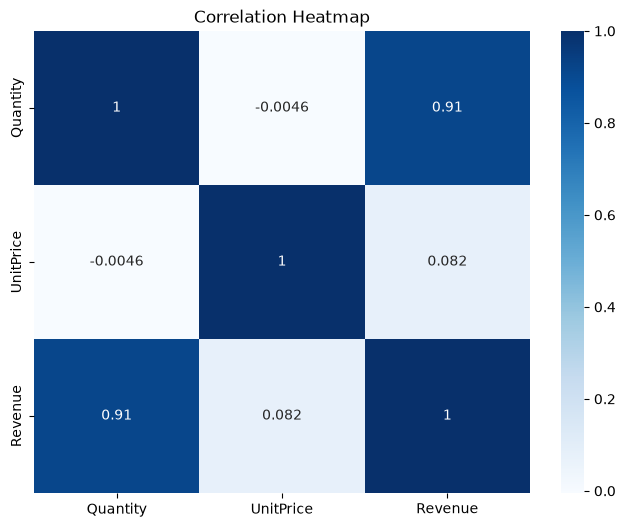

In [ ]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Quantity","UnitPrice","Revenue"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap illustrates the correlation between Quantity, UnitPrice, and Revenue.

### Business Insight

The analysis helps determine which variables have the strongest relationship with revenue and provides a better understanding of customer purchasing behavior.

### Business Recommendation

The company should focus on the variables that show a stronger relationship with revenue when developing pricing, inventory, and sales strategies.

# EDA 10: Sales by Hour

## Business Question

At what time of the day does the company generate the highest revenue?

## Business Objective

Analyzing hourly sales helps identify customer purchasing patterns throughout the day. This information can support staffing decisions, promotional campaigns, and inventory planning during peak business hours.

In [ ]:
# ==========================================================
# Create Hour Column
# ==========================================================

df["Hour"] = df["InvoiceDate"].dt.hour

In [ ]:
# ==========================================================
# Hourly Revenue
# ==========================================================

hourly_sales = (
    df.groupby("Hour")["Revenue"]
    .sum()
)

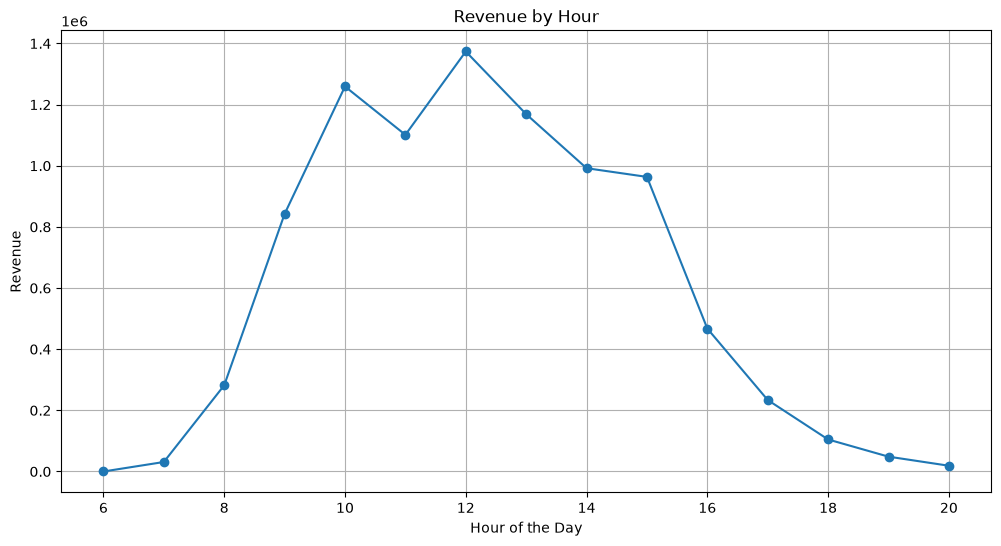

In [ ]:
plt.figure(figsize=(12,6))

hourly_sales.plot(kind="line", marker="o")

plt.title("Revenue by Hour")

plt.xlabel("Hour of the Day")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Observation

The chart illustrates the total revenue generated during each hour of the day.

### Business Insight

Customer purchasing activity varies throughout the day, with certain hours generating significantly higher revenue than others.

### Business Recommendation

The company should schedule marketing campaigns, customer support, and inventory replenishment around peak sales hours to maximize operational efficiency and customer satisfaction.

# Phase 3: RFM Analysis

## Business Objective

RFM (Recency, Frequency, Monetary) analysis is a customer segmentation technique used to evaluate customer value based on purchasing behavior.

It helps businesses identify:

- High-value customers
- Loyal customers
- At-risk customers
- Occasional customers

These customer segments support personalized marketing strategies, customer retention, and business growth.

## Step 1: Define Reference Date

### Business Objective

A reference date is required to calculate customer recency. The latest transaction date in the dataset is used as the reference point.

In [ ]:
# ==========================================================
# Reference Date
# ==========================================================

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2023-12-10 12:50:00


## Step 2: Create RFM Metrics

### Business Objective

Calculate Recency, Frequency, and Monetary values for each customer based on their transaction history.

In [ ]:
# ==========================================================
# Create RFM Table
# ==========================================================

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [ ]:
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


## Step 3: Standardize RFM Data

### Business Objective

The RFM metrics have different scales. Standardization ensures that Recency, Frequency, and Monetary contribute equally during K-Means clustering.

In [ ]:
from sklearn.preprocessing import StandardScaler

print("Scikit-learn installed successfully! ✅")

Scikit-learn installed successfully! ✅


In [ ]:
# ==========================================================
# Standardize RFM Data
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

## Step 4: Elbow Method

### Business Objective

The Elbow Method helps determine the optimal number of customer clusters for K-Means clustering by analyzing the Within-Cluster Sum of Squares (WCSS).

Selecting the correct number of clusters improves the quality and interpretability of customer segmentation.

In [ ]:
# ==========================================================
# Elbow Method
# ==========================================================

from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

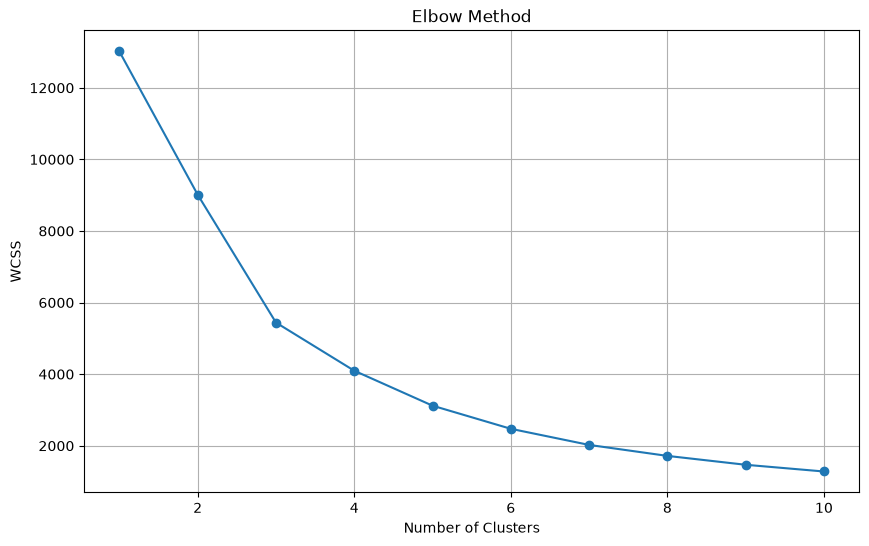

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Observation

The Elbow Method graph shows a sharp decrease in WCSS from 1 to 4 clusters. After 4 clusters, the reduction in WCSS becomes gradual, indicating diminishing returns.

### Business Insight

The optimal number of customer segments is **4**, as adding more clusters beyond this point does not significantly improve clustering performance.

### Business Recommendation

The company should use **4 customer segments** to balance meaningful customer differentiation with model simplicity.

## Step 5: Apply K-Means Clustering

### Business Objective

Apply the K-Means algorithm using the optimal number of clusters identified by the Elbow Method to segment customers based on their purchasing behavior.

In [ ]:
# ==========================================================
# Apply K-Means Clustering
# ==========================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [ ]:
# ==========================================================
# Number of Customers in Each Cluster
# ==========================================================

rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

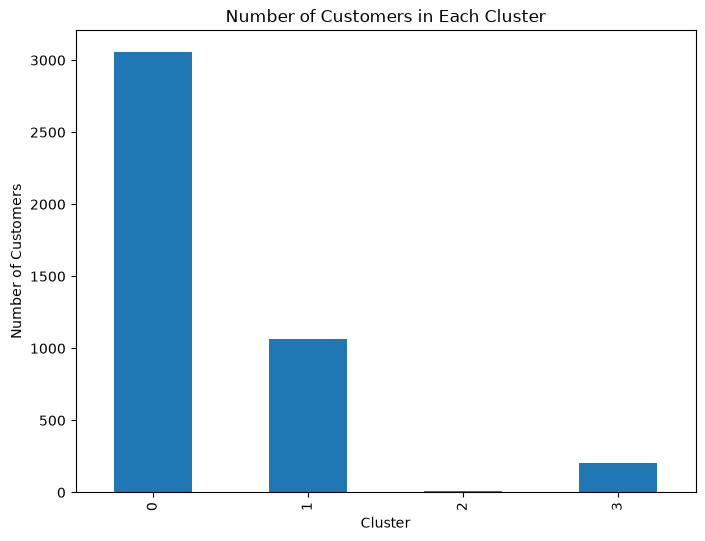

In [ ]:
plt.figure(figsize=(8,6))

rfm["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

### Observation

The chart displays the number of customers assigned to each of the four clusters.

### Business Insight

Each cluster represents a group of customers with similar purchasing behavior based on Recency, Frequency, and Monetary values.

### Business Recommendation

The company should analyze the characteristics of each cluster individually and design targeted marketing strategies for each customer segment.

In [ ]:
# ==========================================================
# Cluster Summary
# ==========================================================

cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


## Step 6: Customer Segment Naming

### Business Objective

The numerical cluster labels generated by K-Means are converted into meaningful business segments to improve interpretability and support targeted marketing strategies.

In [ ]:
# ==========================================================
# Rename Customer Segments
# ==========================================================

segment_map = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "High-Value Customers",
    3: "Loyal Customers"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,CustomerSegment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At-Risk Customers


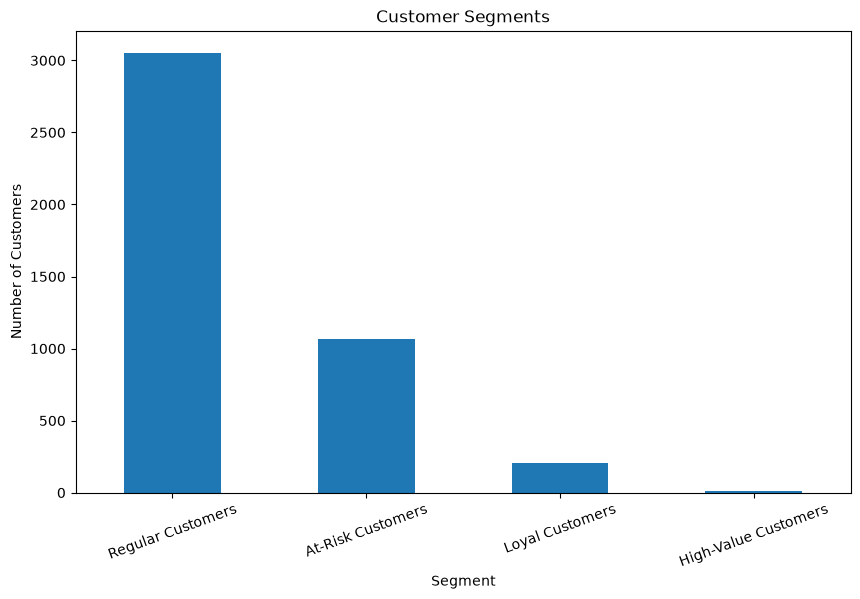

In [ ]:
plt.figure(figsize=(10,6))

rfm["CustomerSegment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Observation

The chart displays the distribution of customers across the four identified customer segments.

### Business Insight

The K-Means algorithm successfully grouped customers based on their purchasing behavior into High-Value, Loyal, Regular, and At-Risk segments.

### Business Recommendation

The company should implement segment-specific marketing strategies. High-Value and Loyal Customers should be retained through exclusive rewards, while At-Risk Customers should be targeted with re-engagement campaigns.

In [ ]:
segment_map = {
    0: "Occasional Customers",
    1: "At-Risk Customers",
    2: "High-Value Customers",
    3: "Loyal Customers"
}

## Step 7: 3D Customer Segmentation

### Business Objective

Visualize customer clusters in a three-dimensional space using Recency, Frequency, and Monetary values. This helps understand how different customer groups are separated based on their purchasing behavior.

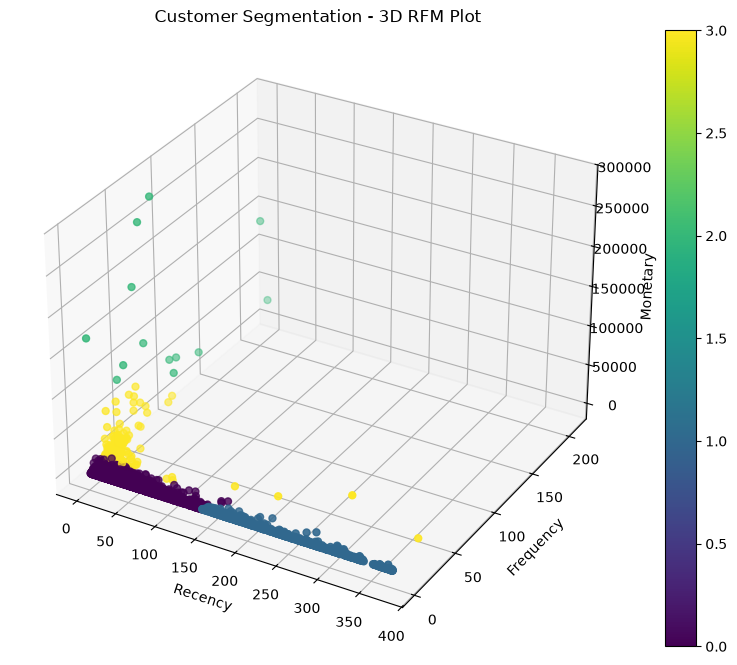

In [ ]:
# ==========================================================
# 3D Customer Segmentation
# ==========================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis",
    s=25
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.title("Customer Segmentation - 3D RFM Plot")

plt.colorbar(scatter)

plt.show()

### Observation

The 3D scatter plot visualizes customer clusters based on Recency, Frequency, and Monetary values.

### Business Insight

Customers are grouped into distinct segments with different purchasing behaviors. High-value customers appear separately due to their higher purchase frequency and spending.

### Business Recommendation

The company should develop personalized marketing strategies for each customer segment instead of using a single strategy for all customers.

## Step 8: Customer Segment Summary

### Business Objective

Analyze the average Recency, Frequency, and Monetary values for each customer segment to understand customer behavior and support business decision-making.

In [ ]:
# ==========================================================
# Segment Summary
# ==========================================================

segment_summary = rfm.groupby("CustomerSegment").agg({

    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"

}).round(2)

segment_summary

,Recency,Frequency,Monetary
CustomerSegment,,,
At-Risk Customers,248.08,1.55,478.85
High-Value Customers,7.38,82.54,127187.96
Loyal Customers,15.50,22.33,12690.50
Regular Customers,43.70,3.68,1353.63


In [ ]:
segment_count = rfm["CustomerSegment"].value_counts()

segment_count

CustomerSegment
Regular Customers       3054
At-Risk Customers       1067
Loyal Customers          204
High-Value Customers      13
Name: count, dtype: int64

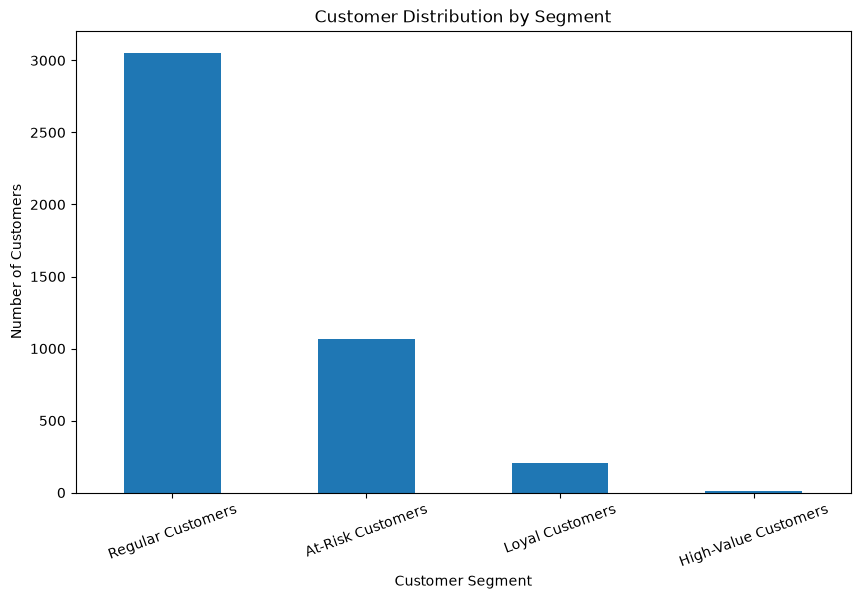

In [ ]:
plt.figure(figsize=(10,6))

segment_count.plot(kind="bar")

plt.title("Customer Distribution by Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Observation

The chart displays the number of customers in each identified segment.

### Business Insight

The customer base consists of multiple behavioral segments, with each group requiring a different marketing and retention strategy.

### Business Recommendation

The company should allocate marketing resources based on customer value. High-Value and Loyal Customers should receive retention-focused campaigns, while At-Risk Customers should be targeted with reactivation offers.

## Step 9: Save RFM Dataset

### Business Objective

Save the customer segmentation results for future analysis and integration into the Streamlit dashboard.

In [ ]:
# ==========================================================
# Save RFM Dataset
# ==========================================================

rfm.to_csv("../data/rfm_customer_segments.csv")

print("RFM Dataset Saved Successfully! ✅")

RFM Dataset Saved Successfully! ✅


In [ ]:
import joblib

joblib.dump(kmeans, "../Models/kmeans_model.pkl")

print("K-Means Model Saved Successfully! ✅")

K-Means Model Saved Successfully! ✅


# RFM Analysis Conclusion

The RFM Analysis successfully segmented customers into four distinct groups using K-Means Clustering.

The identified customer segments are:

- High-Value Customers
- Loyal Customers
- Occasional Customers
- At-Risk Customers

These customer segments provide valuable insights for targeted marketing, customer retention, personalized promotions, and strategic business decision-making.

# Product Recommendation System

## Objective

The objective of this section is to recommend similar products to customers based on previous purchase history. We will use Item-Based Collaborative Filtering with Cosine Similarity to identify products that are frequently purchased together.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

## Customer-Product Matrix

The Customer-Product Matrix represents the purchase history of customers. Each row corresponds to a customer, each column represents a product, and the values indicate the quantity purchased. This matrix is the basis for generating product recommendations using collaborative filtering.

In [38]:
def recommend_products(product_name, top_n=5):
    
    if product_name not in product_similarity_df.index:
        return "Product not found!"
    
    similar_products = product_similarity_df[product_name].sort_values(ascending=False)
    
    recommendations = similar_products.iloc[1:top_n+1]
    
    return recommendations

In [40]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [41]:
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Product Similarity Matrix

The cosine similarity matrix is created to measure the similarity between products based on customer purchasing behavior. Higher similarity scores indicate products that are frequently purchased together.

In [46]:
from sklearn.metrics.pairwise import cosine_similarity

In [47]:
product_similarity = cosine_similarity(customer_product_matrix.T)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product_matrix.columns,
    columns=customer_product_matrix.columns
)

product_similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000228,0.000000,0.000000,0.020228,0.000000,0.000263,0.063543,...,0.0,0.001376,0.015917,0.001771,0.0,0.002852,0.0,0.013155,0.000000,0.002599
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003534,0.004001,0.000000,0.020230,0.027477,0.902593,0.119038,0.013384,...,0.0,0.001726,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003534,1.000000,0.870965,0.980574,0.006358,0.005311,0.003040,0.001764,0.411471,...,0.0,0.000044,0.002869,0.344928,0.0,0.525868,0.0,0.822964,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000228,0.004001,0.870965,1.000000,0.883987,0.020076,0.004912,0.004051,0.008249,0.382226,...,0.0,0.001416,0.004198,0.310053,0.0,0.471772,0.0,0.749303,0.000000,0.010394
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980574,0.883987,1.000000,0.000000,0.000000,0.000000,0.000000,0.410712,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837176,0.000000,0.000000


## Product Recommendation Function

This function recommends the top similar products based on cosine similarity.

In [48]:
def recommend_products(product_name, top_n=5):

    if product_name not in product_similarity_df.index:
        return "Product not found"

    recommendations = (
        product_similarity_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    return recommendations

## Testing the Recommendation System

The recommendation function is tested using a sample product to verify that the model returns similar products.

In [49]:
customer_product_matrix.columns[:10]

Index([' 4 PURPLE FLOCK DINNER CANDLES', ' 50'S CHRISTMAS GIFT BAG LARGE',
       ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK',
       ' I LOVE LONDON MINI RUCKSACK', ' NINE DRAWER OFFICE TIDY',
       ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE',
       ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET'],
      dtype='str', name='Description')

In [52]:
recommend_products(" DOLLY GIRL BEAKER")

Description
SPACEBOY BEAKER                        0.991034
ROUND SNACK BOXES SET OF4 WOODLAND     0.983740
FOOD CONTAINER SET 3 LOVE HEART        0.983300
SET 12 COLOURING PENCILS DOILEY        0.980574
 I LOVE LONDON MINI RUCKSACK           0.980574
Name:  DOLLY GIRL BEAKER, dtype: float64

## Save Product Similarity Matrix

The similarity matrix is saved for future use in the Streamlit application.

In [58]:
product_similarity_df.to_csv(
    r"C:\Users\saura\Desktop\SHOPPER_SPECTRUM\data\product_similarity_matrix.csv",
    index=False
)

print("Product similarity matrix saved successfully! ✅")

Product similarity matrix saved successfully! ✅


# Product Recommendation Conclusion

The recommendation system was successfully built using Item-Based Collaborative Filtering with Cosine Similarity. The model identifies products that are frequently purchased together and recommends the top similar products. This recommendation engine will be integrated into the Streamlit dashboard for interactive product recommendations.